In [2]:
import cv2
import matplotlib.pyplot as plt
import os
from skimage import io, filters, segmentation, feature, exposure
from skimage.util import random_noise
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.summary()

21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 47s 2us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_4         │ (None, 224, 224,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_2     │ (None, 224, 224,  │          7 │ rescaling_4[0][0] │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_5         │ (None, 224, 224,  │          0 │ normalization_2[… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_5[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 5,330,571 (20.33 MB)

 Trainable params: 5,288,548 (20.17 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [11]:
print("=== EfficientNetB0 preprocessing layers ===")

for i, layer in enumerate(base_model.layers):
    if isinstance(layer, (
        tf.keras.layers.Rescaling,
        tf.keras.layers.Normalization
    )):
        print(i, layer.name, type(layer).__name__)

=== EfficientNetB0 preprocessing layers ===
1 rescaling_4 Rescaling
2 normalization_2 Normalization
3 rescaling_5 Rescaling


In [2]:
DATA_DIR = r"C:\Users\AddisCoder\Desktop\banana disease classification final\data"

In [ ]:

print(os.listdir(DATA_DIR))

['cordana', 'healthy', 'Panama Disease', 'sigatoka']


In [4]:
image_path = r"C:\Users\AddisCoder\Desktop\banana disease classification final\data\healthy\6.jpeg"

img = cv2.imread(image_path)

if img is None:
    print("Image not found.")
else:
    print("Image loaded successfully.")
    print("Original shape:", img.shape)

Image loaded successfully.
Original shape: (224, 224, 3)


In [5]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

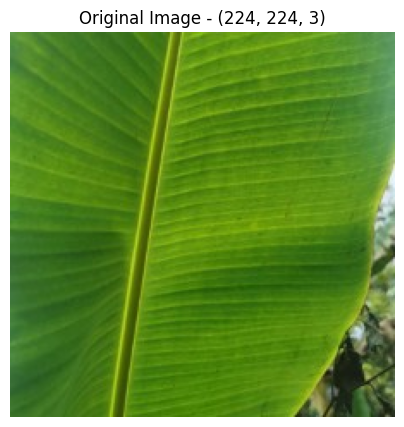

In [ ]:
plt.figure(figsize=(5, 5))
plt.imshow(img_rgb)
plt.title(f"Original Image - {img_rgb.shape}")
plt.axis("off")
plt.show()

Loaded: True
Original shape: (224, 224, 3)
Bilinear shape: (224, 224, 3)


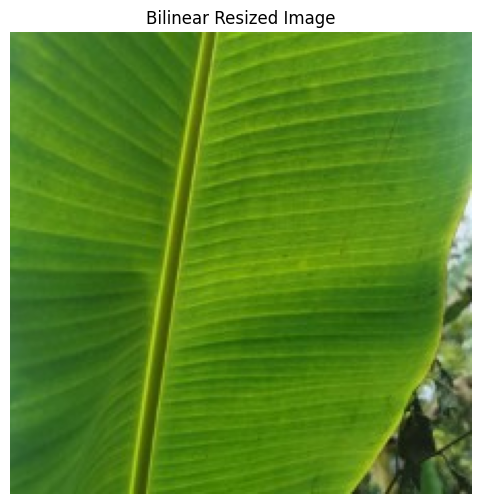

In [ ]:

IMAGE_SIZE = (224, 224)

image_path = r"C:\Users\AddisCoder\Desktop\banana disease classification final\data\healthy\6.jpeg"

img = cv2.imread(image_path)

print("Loaded:", img is not None)

if img is not None:

    # Convert BGR to RGB
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Bilinear resizing
    bilinear = cv2.resize(
        img_rgb,
        IMAGE_SIZE,
        interpolation=cv2.INTER_LINEAR
    )

    print("Original shape:", img_rgb.shape)
    print("Bilinear shape:", bilinear.shape)

    # Display
    plt.figure(figsize=(6, 6))
    plt.imshow(bilinear)
    plt.title("Bilinear Resized Image")
    plt.axis("off")
    plt.show()

In [8]:
def resize_images(image_paths, interpolation):
    images = []

    for path in image_paths:
        img = cv2.imread(path)

        if img is None:
            print("Could not read:", path)
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        resized = cv2.resize(
            img,
            IMAGE_SIZE,
            interpolation=interpolation
        )

        images.append(resized)

    return np.array(images)

In [ ]:

DATA_DIR = r"C:\Users\AddisCoder\Desktop\banana disease classification final\data"
IMAGE_SIZE = (224, 224)

In [11]:
classes = os.listdir(DATA_DIR)  # Assuming class_names is defined earlier in the code

image_paths = []
labels = []

for label, class_name in enumerate(classes):

    class_dir = os.path.join(DATA_DIR, class_name)

    for filename in os.listdir(class_dir):

        file_path = os.path.join(class_dir, filename)

        # Only process image files
        if filename.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")):

            image_paths.append(file_path)
            labels.append(label)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 4642
Total labels: 4642


In [12]:
from collections import Counter

print(Counter(labels))

for i, class_name in enumerate(classes):
    print(f"{class_name}: {labels.count(i)}")

Counter({3: 1483, 1: 1134, 2: 1122, 0: 903})
cordana: 903
healthy: 1134
Panama Disease: 1122
sigatoka: 1483


In [13]:
from sklearn.model_selection import train_test_split

X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", len(X_train_paths))
print("Validation:", len(X_val_paths))
print("Test:", len(X_test_paths))

Train: 3249
Validation: 696
Test: 697


In [15]:
X_train_bilinear = resize_images_bilinear(X_train_paths)
X_val_bilinear = resize_images_bilinear(X_val_paths)
X_test_bilinear = resize_images_bilinear(X_test_paths)

In [16]:
print("Train:", X_train_bilinear.shape)
print("Validation:", X_val_bilinear.shape)
print("Test:", X_test_bilinear.shape)

Train: (3249, 224, 224, 3)
Validation: (696, 224, 224, 3)
Test: (697, 224, 224, 3)


In [17]:
print("Train images :", len(X_train_bilinear))
print("Train labels :", len(y_train))

print("Validation images :", len(X_val_bilinear))
print("Validation labels :", len(y_val))

print("Test images :", len(X_test_bilinear))
print("Test labels :", len(y_test))

Train images : 3249
Train labels : 3249
Validation images : 696
Validation labels : 696
Test images : 697
Test labels : 697


In [18]:
print("Data type:", X_train_bilinear.dtype)
print("Minimum pixel:", X_train_bilinear.min())
print("Maximum pixel:", X_train_bilinear.max())

Data type: uint8
Minimum pixel: 0
Maximum pixel: 255


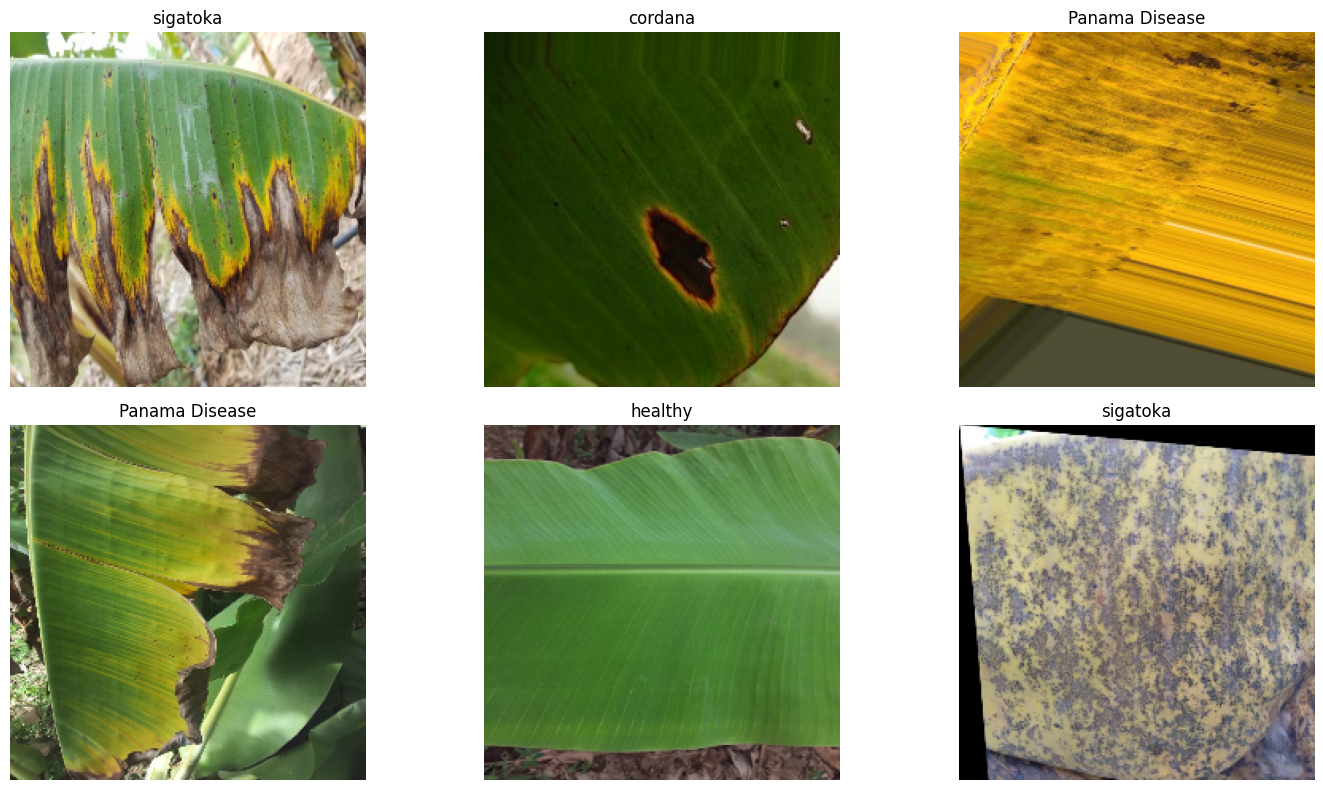

In [19]:
plt.figure(figsize=(15, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train_bilinear[i])
    plt.title(classes[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

Noise removal

bilateral is choosed here

selecting the denoised image

 converting to the grayscale

# denoising
It smooths unwanted noise while trying to preserve important edges, such as the boundary between healthy and diseased parts of a leaf.
# Grayscale
Simplify RGB into one intensity channel
# Gaussian Blur	
Smooth the image before segmentation
# Global Threshold
Separate pixels into different regions

In [20]:
print("Minimum pixel:", X_train_bilinear.min())
print("Maximum pixel:", X_train_bilinear.max())
print("Data type:", X_train_bilinear.dtype)

Minimum pixel: 0
Maximum pixel: 255
Data type: uint8


"EfficientNetB0 is used as a pretrained feature extractor. It looks at the image and extracts useful visual features such as shapes, textures, colors, and disease patterns."

In [ ]:
# Input
inputs = layers.Input(shape=(224, 224, 3))

# EfficientNetB0 base
base_model = EfficientNetB0(
    include_top=False, 
    weights="imagenet",
    input_tensor=inputs
)

# Freeze the pretrained layers
base_model.trainable = False   # keep the already learned features

# Feature extraction
x = base_model(inputs, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)  # summarizes the extracted feature maps into 1280 values
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)

# 4 disease classes
outputs = layers.Dense(
    4,
    activation="softmax"
)(x)

model = Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [23]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_bilinear, y_train)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val_bilinear, y_val)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test_bilinear, y_test)
)

In [24]:
train_ds = train_ds.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(32).prefetch(tf.data.AUTOTUNE)

In [25]:
images, labels = next(iter(train_ds))

print("Images:", images.shape)
print("Labels:", labels.shape)
print("Labels:", labels[:10].numpy())

Images: (32, 224, 224, 3)
Labels: (32,)
Labels: [1 2 2 0 1 2 3 0 0 3]


In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau

)


callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        "best_efficientnetb0.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=0.0001,
        verbose=1
    )
]

In [28]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Epoch 1/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7122 - loss: 0.6974
Epoch 1: val_loss improved from None to 0.11310, saving model to best_efficientnetb0.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.8538 - loss: 0.3937 - val_accuracy: 0.9612 - val_loss: 0.1131 - learning_rate: 0.0010
Epoch 2/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.9390 - loss: 0.1603
Epoch 2: val_loss improved from 0.11310 to 0.08164, saving model to best_efficientnetb0.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9468 - loss: 0.1430 - val_accuracy: 0.9684 - val_loss: 0.0816 - learning_rate: 0.0010
Epoch 3/15
102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 834ms/step - accuracy: 0.9747 - loss: 0.0819
Epoch 3: val_loss improved from 0.08164 to 0.05793, saving model to best_efficientnetb0.keras
102/102 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.9711 - loss: 0.0853 - val_accuracy: 0.9727 - val_loss: 0.0579 - learning_rate: 0.0010
Epoch 4/15
102/102 ━━━━━━━━━━━━━━━

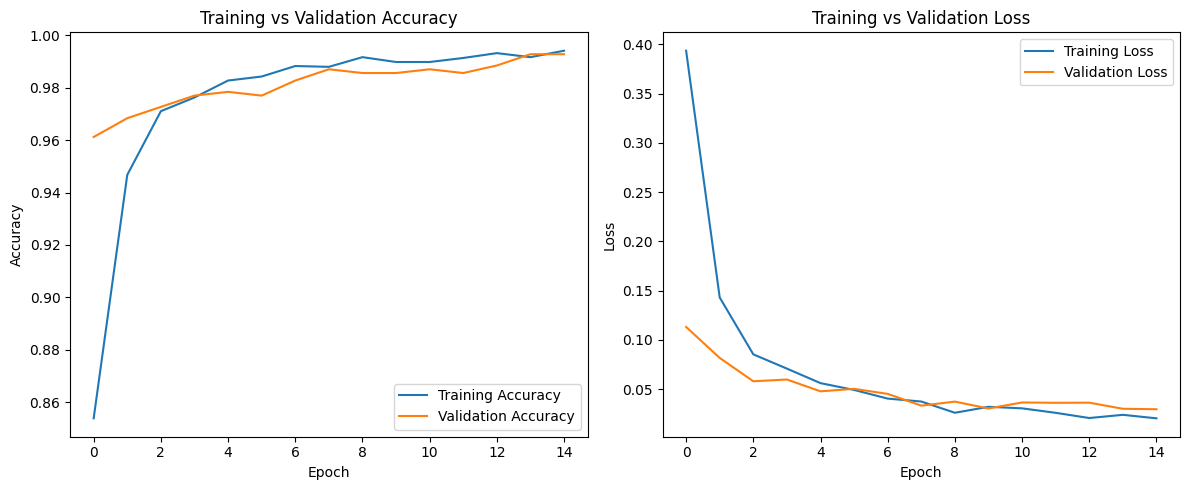

In [29]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [30]:
test_loss, test_accuracy = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9857 - loss: 0.0519
Test Loss: 0.0519
Test Accuracy: 0.9857


In [31]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

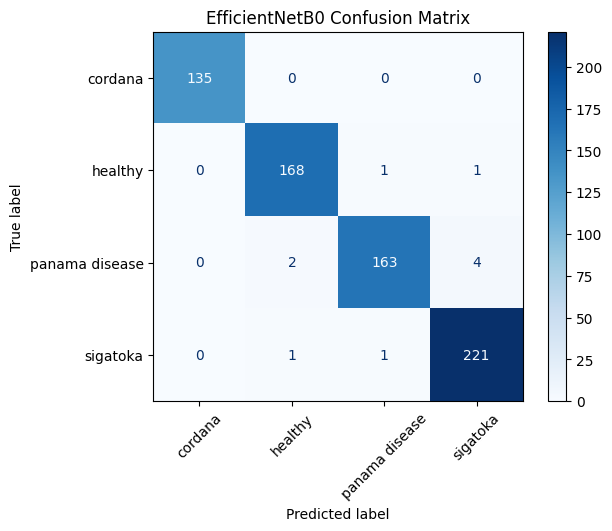

In [32]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["cordana", "healthy", "panama disease", "sigatoka"]
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("EfficientNetB0 Confusion Matrix")
plt.show()

In [34]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=["cordana", "healthy", "panama disease", "sigatoka"]
    
))

                precision    recall  f1-score   support

       cordana       1.00      1.00      1.00       135
       healthy       0.98      0.99      0.99       170
panama disease       0.99      0.96      0.98       169
      sigatoka       0.98      0.99      0.98       223

      accuracy                           0.99       697
     macro avg       0.99      0.99      0.99       697
  weighted avg       0.99      0.99      0.99       697



In [ ]:
image_path = r"C:\Users\AddisCoder\Pictures\images (2).jfif"

In [38]:
image_batch = np.expand_dims(image, axis=0)

probabilities = model.predict(image_batch, verbose=0)[0]

for class_name, probability in zip(classes, probabilities):
    print(f"{class_name}: {probability * 100:.2f}%")

cordana: 0.09%
healthy: 18.42%
Panama Disease: 21.31%
sigatoka: 60.18%


In [41]:
predicted_index = np.argmax(probabilities)

print("\nPredicted class:", classes[predicted_index])
print("Confidence:", f"{probabilities[predicted_index] * 100:.2f}%")


Predicted class: sigatoka
Confidence: 60.18%


In [ ]:
model.save("best_efficientnetb0.keras")